In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

C:\Users\Pranav Sarda\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [6]:
df=pd.read_excel('OCM_Actual_Datapoint.xlsx')

In [7]:
df

,Amount of Catalyst(g),T[K],T[C],Flow Rate[ml/min],GHSV(ml/min/g),CH4/O2,N2 Dilution,O2[%],CH4[%],N2[%],X_CH4[%],S_C2H6,Y_C2H6,S_C2H4,Y_C2H4,S_C2,S_C2+,S_CO,S_CO2
0,0.75,1023,750,120,160,1.5,0.00,28.6,26.2,-0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.75,1023,750,120,160,1.5,0.25,21.4,19.7,16.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.75,1023,750,120,160,1.5,0.50,14.2,13.1,34.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.75,1023,750,120,160,2.0,0.00,23.8,29.2,-0.9,44.8,10.8,4.9,33.3,14.9,44.1,47.7,29.6,22.6
4,0.75,1023,750,120,160,2.0,0.25,17.8,21.9,16.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,0.75,1148,875,240,320,6.0,0.25,15.2,56.2,34.8,9.5,43.8,4.2,31.5,3.0,75.3,77.6,14.4,8.0
626,0.75,1148,875,240,320,6.0,0.50,10.1,37.5,70.5,8.0,49.9,4.0,28.3,2.3,78.2,78.2,13.2,8.7
627,0.75,1148,875,240,320,10.0,0.00,12.9,79.5,-0.9,7.2,49.3,3.5,29.9,2.2,79.2,81.4,11.5,7.0
628,0.75,1148,875,240,320,10.0,0.25,9.6,59.6,34.8,6.6,52.4,3.5,27.6,1.8,80.0,81.8,10.9,7.3


In [8]:
df.isna().sum()

Amount of Catalyst(g)    0
T[K]                     0
T[C]                     0
Flow Rate[ml/min]        0
GHSV(ml/min/g)           0
CH4/O2                   0
N2 Dilution              0
O2[%]                    0
CH4[%]                   0
N2[%]                    0
X_CH4[%]                 0
S_C2H6                   0
Y_C2H6                   0
S_C2H4                   0
Y_C2H4                   0
S_C2                     0
S_C2+                    0
S_CO                     0
S_CO2                    0
dtype: int64

In [9]:
df.columns

Index(['Amount of Catalyst(g)', 'T[K]', 'T[C]', 'Flow Rate[ml/min]',
       'GHSV(ml/min/g)', 'CH4/O2', 'N2 Dilution', 'O2[%]', 'CH4[%]', 'N2[%]',
       'X_CH4[%]', 'S_C2H6', 'Y_C2H6', 'S_C2H4', 'Y_C2H4', 'S_C2', 'S_C2+',
       'S_CO', 'S_CO2'],
      dtype='object')

In [10]:
df = df.drop(columns=['T[C]','O2[%]','N2[%]','S_C2H6', 'Y_C2H6','S_C2H4','S_C2+',
       'S_CO', 'S_CO2','Amount of Catalyst(g)'])

In [11]:
df=df.astype(np.float64)

In [12]:
df.describe()

,T[K],Flow Rate[ml/min],GHSV(ml/min/g),CH4/O2,N2 Dilution,CH4[%],X_CH4[%],Y_C2H4,S_C2
count,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000
mean,1085.500000,180.000000,240.000000,4.142857,0.250000,37.230476,13.764444,3.943175,50.352222
std,42.729554,42.460119,56.613492,2.763072,0.204286,14.598507,13.929935,4.776893,21.542973
min,1023.000000,120.000000,160.000000,1.500000,0.000000,13.100000,0.000000,0.000000,0.000000
25%,1048.000000,150.000000,200.000000,2.000000,0.000000,26.200000,3.300000,0.300000,42.950000
50%,1085.500000,180.000000,240.000000,3.000000,0.250000,35.000000,7.950000,1.400000,54.150000
75%,1123.000000,210.000000,280.000000,6.000000,0.500000,46.900000,21.400000,6.725000,65.175000
max,1148.000000,240.000000,320.000000,10.000000,0.500000,79.500000,54.300000,17.000000,91.300000


In [13]:
df

,T[K],Flow Rate[ml/min],GHSV(ml/min/g),CH4/O2,N2 Dilution,CH4[%],X_CH4[%],Y_C2H4,S_C2
0,1023.0,120.0,160.0,1.5,0.00,26.2,0.0,0.0,0.0
1,1023.0,120.0,160.0,1.5,0.25,19.7,0.0,0.0,0.0
2,1023.0,120.0,160.0,1.5,0.50,13.1,0.0,0.0,0.0
3,1023.0,120.0,160.0,2.0,0.00,29.2,44.8,14.9,44.1
4,1023.0,120.0,160.0,2.0,0.25,21.9,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
625,1148.0,240.0,320.0,6.0,0.25,56.2,9.5,3.0,75.3
626,1148.0,240.0,320.0,6.0,0.50,37.5,8.0,2.3,78.2
627,1148.0,240.0,320.0,10.0,0.00,79.5,7.2,2.2,79.2
628,1148.0,240.0,320.0,10.0,0.25,59.6,6.6,1.8,80.0


In [14]:
import seaborn as sns

C:\Users\Pranav Sarda\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Pranav Sarda\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Pranav Sarda\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Pranav Sarda\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

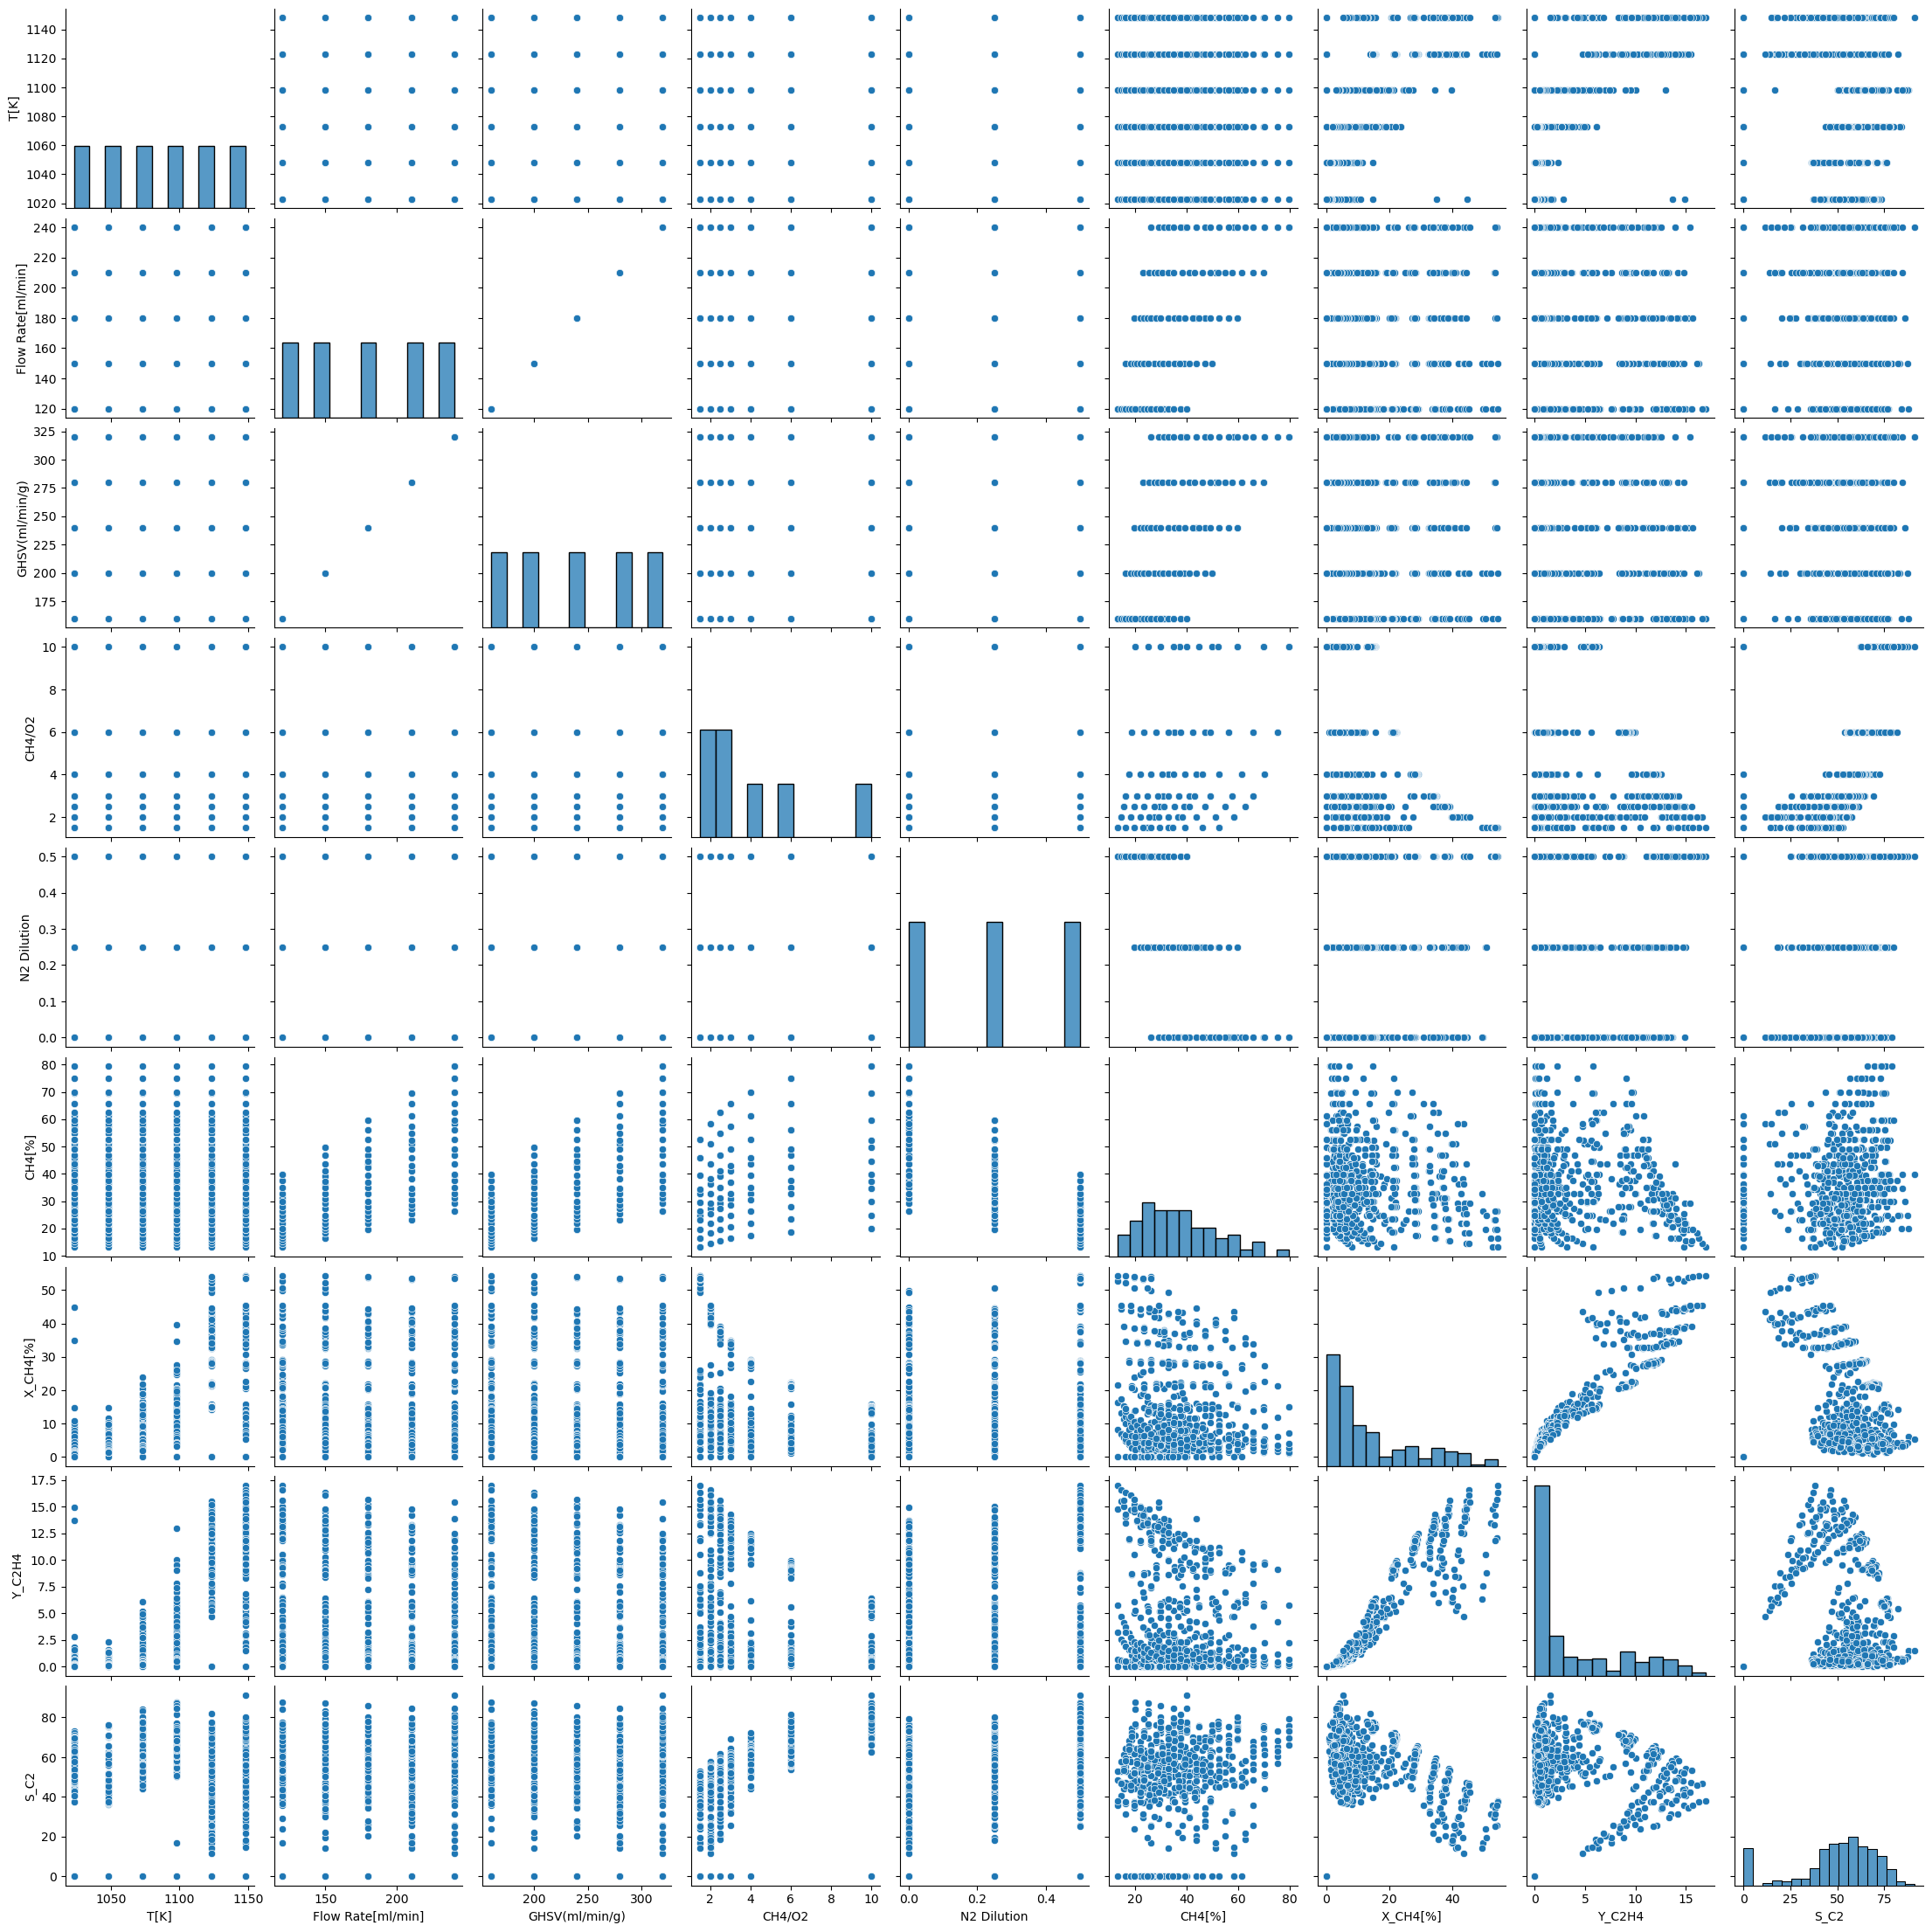

In [15]:
sns.pairplot(df)

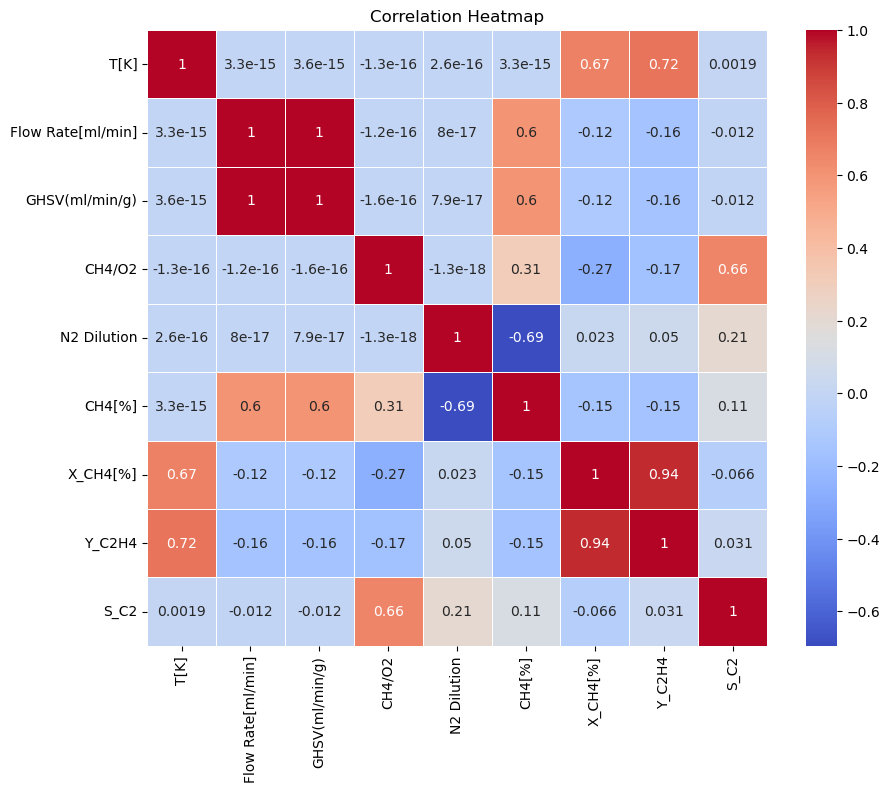

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

training and testing

In [17]:
df.rename(columns = {'T[K]':'T(K)','Flow Rate[ml/min]':'Flow Rate(ml/min)','CH4[%]':'CH4(%)','X_CH4[%]':'X_CH4(%)'}, inplace = True)
print(df.columns)

Index(['T(K)', 'Flow Rate(ml/min)', 'GHSV(ml/min/g)', 'CH4/O2', 'N2 Dilution',
       'CH4(%)', 'X_CH4(%)', 'Y_C2H4', 'S_C2'],
      dtype='object')


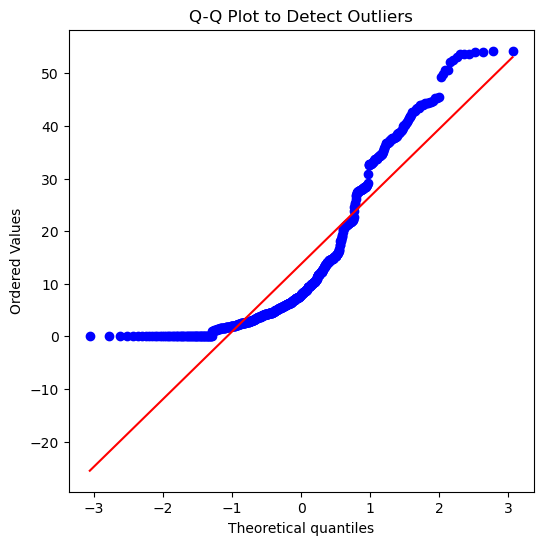

Original data size: 630
Data size after removing outliers: 630


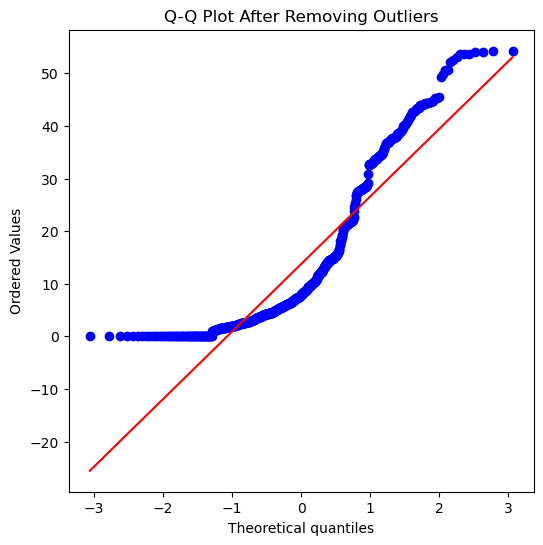

In [18]:
import scipy.stats as stats
# 1. Q-Q Plot for visualizing outliers
plt.figure(figsize=(6, 6))
stats.probplot(df['X_CH4(%)'], dist="norm", plot=plt)
plt.title("Q-Q Plot to Detect Outliers")
plt.show()

# 2. Calculate Z-scores to identify outliers
df['Z_score'] = np.abs(stats.zscore(df['X_CH4(%)']))

# 3. Set a threshold to remove outliers (e.g., Z-score > 3)
threshold = 3
df_cleaned = df[df['Z_score'] < threshold]

# View the cleaned data
print(f"Original data size: {df.shape[0]}")
print(f"Data size after removing outliers: {df_cleaned.shape[0]}")

# Optional: Plot Q-Q plot for cleaned data
plt.figure(figsize=(6, 6))
stats.probplot(df_cleaned['X_CH4(%)'], dist="norm", plot=plt)
plt.title("Q-Q Plot After Removing Outliers")
plt.show()

C:\Users\Pranav Sarda\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


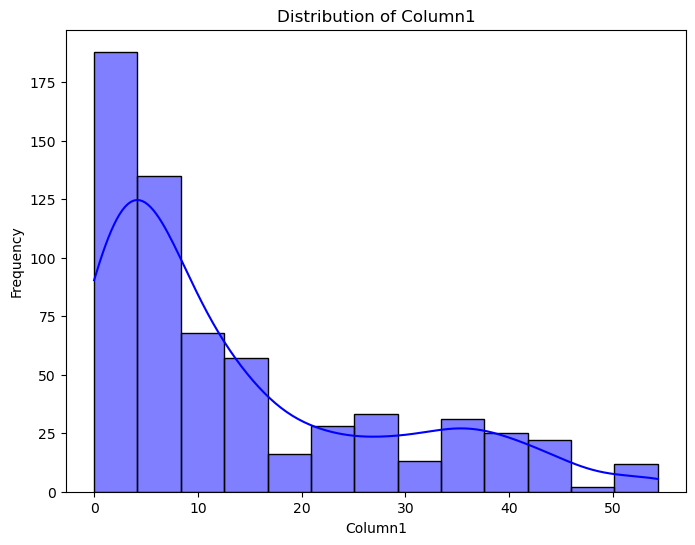

In [20]:
plt.figure(figsize=(8, 6))
sns.histplot(df['X_CH4(%)'], kde=True, color='blue')
plt.title('Distribution of Column1')
plt.xlabel('Column1')
plt.ylabel('Frequency')
plt.show()

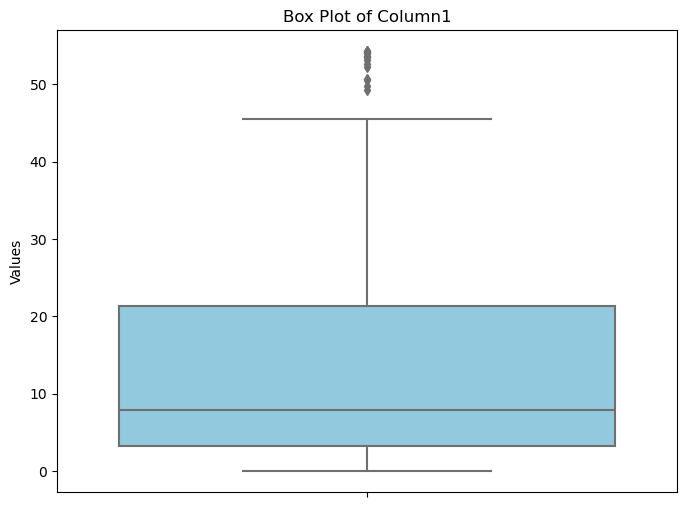

In [21]:
# Plot a box plot for 'Column1'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['X_CH4(%)'], color='skyblue')

# Add titles and labels
plt.title('Box Plot of Column1')
plt.ylabel('Values')

# Show the plot
plt.show()

In [22]:

# Step 1: Calculate the IQR for 'Column1'
Q1 = df['X_CH4(%)'].quantile(0.25)
Q3 = df['X_CH4(%)'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Remove outliers by filtering the DataFrame
df_cleaned = df[(df['X_CH4(%)'] >= lower_bound) & (df['X_CH4(%)'] <= upper_bound)]

# View the cleaned data
print(f"Original data size: {df.shape[0]}")
print(f"Data size after removing outliers: {df_cleaned.shape[0]}")


Original data size: 630
Data size after removing outliers: 616


In [23]:
df_cleaned

,T(K),Flow Rate(ml/min),GHSV(ml/min/g),CH4/O2,N2 Dilution,CH4(%),X_CH4(%),Y_C2H4,S_C2,Z_score
0,1023.0,120.0,160.0,1.5,0.00,26.2,0.0,0.0,0.0,0.988905
1,1023.0,120.0,160.0,1.5,0.25,19.7,0.0,0.0,0.0,0.988905
2,1023.0,120.0,160.0,1.5,0.50,13.1,0.0,0.0,0.0,0.988905
3,1023.0,120.0,160.0,2.0,0.00,29.2,44.8,14.9,44.1,2.229746
4,1023.0,120.0,160.0,2.0,0.25,21.9,0.0,0.0,0.0,0.988905
...,...,...,...,...,...,...,...,...,...,...
625,1148.0,240.0,320.0,6.0,0.25,56.2,9.5,3.0,75.3,0.306379
626,1148.0,240.0,320.0,6.0,0.50,37.5,8.0,2.3,78.2,0.414146
627,1148.0,240.0,320.0,10.0,0.00,79.5,7.2,2.2,79.2,0.471622
628,1148.0,240.0,320.0,10.0,0.25,59.6,6.6,1.8,80.0,0.514729


In [24]:
df=df_cleaned

In [25]:
df.describe()

,T(K),Flow Rate(ml/min),GHSV(ml/min/g),CH4/O2,N2 Dilution,CH4(%),S_C2H4,Y_C2H4,S_C2,Z_score
count,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000
mean,1085.500000,180.000000,240.000000,4.142857,0.250000,37.230476,19.141905,3.943175,50.352222,0.861342
std,42.729554,42.460119,56.613492,2.763072,0.204286,14.598507,13.248317,4.776893,21.542973,0.508429
min,1023.000000,120.000000,160.000000,1.500000,0.000000,13.100000,0.000000,0.000000,0.000000,0.003166
25%,1048.000000,150.000000,200.000000,2.000000,0.000000,26.200000,8.000000,0.300000,42.950000,0.459219
50%,1085.500000,180.000000,240.000000,3.000000,0.250000,35.000000,17.350000,1.400000,54.150000,0.837897
75%,1123.000000,210.000000,280.000000,6.000000,0.500000,46.900000,30.000000,6.725000,65.175000,1.364131
max,1148.000000,240.000000,320.000000,10.000000,0.500000,79.500000,44.400000,17.000000,91.300000,1.908028


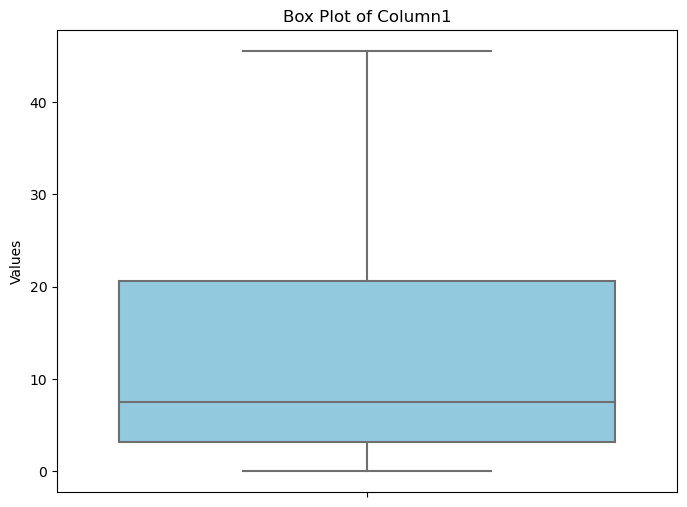

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame (replace with your data)
# Plot a box plot for 'Column1'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['X_CH4(%)'], color='skyblue')

# Add titles and labels
plt.title('Box Plot of Column1')
plt.ylabel('Values')

# Show the plot
plt.show()


In [26]:
X=df.iloc[:,:-4]

In [27]:
X

,T(K),Flow Rate(ml/min),GHSV(ml/min/g),CH4/O2,N2 Dilution,CH4(%)
0,1023.0,120.0,160.0,1.5,0.00,26.2
1,1023.0,120.0,160.0,1.5,0.25,19.7
2,1023.0,120.0,160.0,1.5,0.50,13.1
3,1023.0,120.0,160.0,2.0,0.00,29.2
4,1023.0,120.0,160.0,2.0,0.25,21.9
...,...,...,...,...,...,...
625,1148.0,240.0,320.0,6.0,0.25,56.2
626,1148.0,240.0,320.0,6.0,0.50,37.5
627,1148.0,240.0,320.0,10.0,0.00,79.5
628,1148.0,240.0,320.0,10.0,0.25,59.6


In [28]:
y=df['X_CH4(%)']

# Models

In [31]:

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
cv = LeaveOneOut()

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state=123)

# XGBOOST

In [33]:
import xgboost
from xgboost import XGBRegressor
model =  XGBRegressor(colsample_bytree = 1, booster= 'gbtree', eta = 0.1, eval_metric = 'rmse', 
                        max_depth = 8, n_estimators = 350, seed = 4, subsample = 0.8, reg_lambda=0.95)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eta=0.1, eval_metric='rmse', feature_types=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=350, n_jobs=None,
             num_parallel_tree=None, ...)

In [34]:
y2_pred=model.predict(X_test)
r2_score(y_test,y2_pred)

0.7983260392822213

In [35]:
y3_pred=model.predict(X_train)
r2_score(y_train,y3_pred)

0.9999999399733949

In [36]:
y_pred=model.predict(X)
r2_score(y,y_pred)

0.953530050245842

In [37]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_test,y2_pred,squared=False)
# report error
print(errors)

5.505550849381676


C:\Users\Pranav Sarda\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [38]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_train,y3_pred,squared=False)
# report error
print(errors)

0.0031691779732676032


C:\Users\Pranav Sarda\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [39]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# Assuming X and y are your features and labels, and model is your model instance
k = 3

# Create a KFold object
kf = KFold(n_splits=k, random_state=110, shuffle=True)

acc_score = []

# Loop through each of the k-fold splits
for train_index, test_index in kf.split(X):
    # Use iloc to select rows by index
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model on the train set
    model.fit(X_train, y_train)

    # Predict on the test set
    pred_values = model.predict(X_test)

    # Calculate the accuracy score
    acc = r2_score(y_test, pred_values)

    # Append the score to the list
    acc_score.append(acc)

# Calculate the average accuracy score
avg_acc_score = sum(acc_score) / k

print(f"Average R2 Score: {avg_acc_score}")


#print the results
print('Accuracy of each fold - {}'.format(acc_score))
print('Average accuracy - {}'.format(avg_acc_score))


Average R2 Score: 0.8737919960342225
Accuracy of each fold - [0.8591593509670117, 0.8967628965879488, 0.8654537405477072]
Average accuracy - 0.8737919960342225


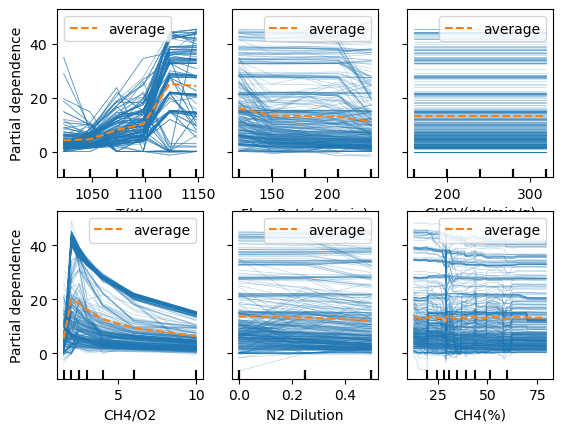

In [41]:
from sklearn.inspection import PartialDependenceDisplay

import matplotlib
%matplotlib inline

 
import matplotlib.pyplot as plt
# List of features you want to plot the partial dependence for
features = X.columns  # You can specify feature indices or names

# Generate the PDP
PartialDependenceDisplay.from_estimator(model, X_train, features, grid_resolution=500, kind='both')


# Show the plot
plt.show()


In [ ]:
print(matplotlib.get_backend())


# GradientBoost

In [233]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(random_state=412)
model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=412)

In [234]:
y2_pred=model.predict(X_test)
r2_score(y_test,y2_pred)

0.871937370569483

In [235]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_test,y2_pred,squared=False)
# report error
print(errors)

4.620785611524179


'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


In [236]:
y3_pred=model.predict(X_train)
r2_score(y_train,y3_pred)

0.9128082019291762

In [237]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_train,y3_pred,squared=False)
# report error
print(errors)

3.759249505614148


'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


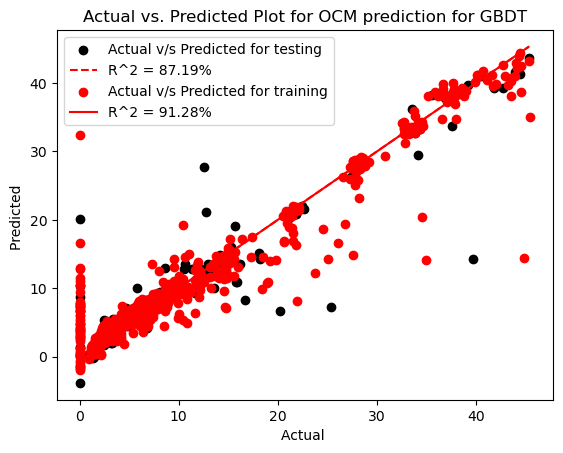

In [238]:
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(y_test, y2_pred, color='black', label='Actual v/s Predicted for testing')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label=f'R^2 = {r2_score(y_test,y2_pred)*100:.2f}%')

# Add labels and legend
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
#plt.title('Actual vs. Predicted Plot (RF model) for biooil yield on testing dataset')
plt.legend()

# Show the plot
#plt.show()
plt.scatter(y_train, y3_pred, color='red', label='Actual v/s Predicted for training')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red',  label= f'R^2 = {r2_score(y_train,y3_pred)*100:.2f}%')

# Add labels and legend
plt.xlabel('Actual ')
plt.ylabel('Predicted ')
plt.title('Actual vs. Predicted Plot for OCM prediction for GBDT')
plt.legend()

# Show the plot
plt.show()

In [239]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# Assuming X and y are your features and labels, and model is your model instance
k = 5

# Create a KFold object
kf = KFold(n_splits=k, random_state=1010, shuffle=True)

acc_score = []

# Loop through each of the k-fold splits
for train_index, test_index in kf.split(X):
    # Use iloc to select rows by index
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model on the train set
    model.fit(X_train, y_train)

    # Predict on the test set
    pred_values = model.predict(X_test)

    # Calculate the accuracy score
    acc = r2_score(y_test, pred_values)

    # Append the score to the list
    acc_score.append(acc)

# Calculate the average accuracy score
avg_acc_score = sum(acc_score) / k

print(f"Average R2 Score: {avg_acc_score}")


#print the results
print('Accuracy of each fold - {}'.format(acc_score))
print('Average accuracy - {}'.format(avg_acc_score))

Average R2 Score: 0.846313582659954
Accuracy of each fold - [0.7785922867316812, 0.7766422748563772, 0.8849734556831285, 0.9194225254591009, 0.871937370569483]
Average accuracy - 0.846313582659954


if u r splitting in catboost wala k-fold that will give the best accuracy. for DT, Extratrees, and even catboost

# DecisionTreeRegressor

In [315]:

# import the regressor 
from sklearn.tree import DecisionTreeRegressor  
# create a regressor object 
model = DecisionTreeRegressor(random_state = 122,max_depth=20,max_features=5)  
  
# fit the regressor with X and Y data 
model.fit(X_train, y_train) 

DecisionTreeRegressor(max_depth=20, max_features=5, random_state=122)

In [311]:
y2_pred=model.predict(X_test)
r2_score(y_test,y2_pred)

0.9275277594414165

In [312]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_test,y2_pred,squared=False)
# report error
print(errors)

3.4760855472366208


'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


In [313]:
y3_pred=model.predict(X_train)
r2_score(y_train,y3_pred)

0.9999994994051201

In [314]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_train,y3_pred,squared=False)
# report error
print(errors)

0.009007546982220708


'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


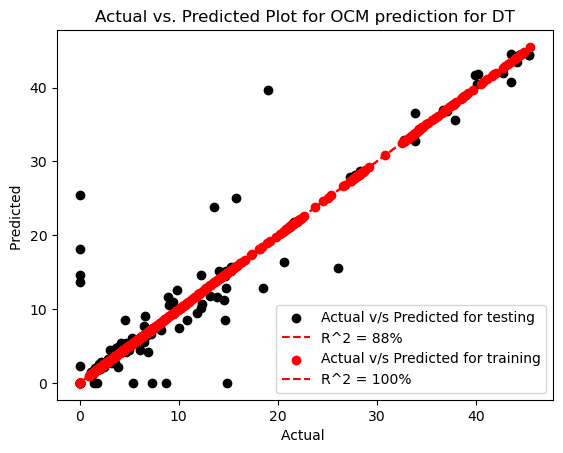

In [295]:
import math
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(y_test, y2_pred, color='black', label='Actual v/s Predicted for testing')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label=f'R^2 = {r2_score(y_test,y2_pred)*100:.0f}%')

# Add labels and legend
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
#plt.title('Actual vs. Predicted Plot (RF model) for biooil yield on testing dataset')
plt.legend()

# Show the plot
#plt.show()
plt.scatter(y_train, y3_pred, color='red', label='Actual v/s Predicted for training')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label= f'R^2 = {math.floor(r2_score(y_train,y3_pred)*100)}%')

# Add labels and legend
plt.xlabel('Actual ')
plt.ylabel('Predicted ')
plt.title('Actual vs. Predicted Plot for OCM prediction for DT')
plt.legend()

# Show the plot
plt.show()

In [289]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# Assuming X and y are your features and labels, and model is your model instance
k = 5

# Create a KFold object
kf = KFold(n_splits=k, random_state=42, shuffle=True)

acc_score = []

# Loop through each of the k-fold splits
for train_index, test_index in kf.split(X):
    # Use iloc to select rows by index
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model on the train set
    model.fit(X_train, y_train)

    # Predict on the test set
    pred_values = model.predict(X_test)

    # Calculate the accuracy score
    acc = r2_score(y_test, pred_values)

    # Append the score to the list
    acc_score.append(acc)

# Calculate the average accuracy score
avg_acc_score = sum(acc_score) / k

print(f"Average R2 Score: {avg_acc_score}")


#print the results
print('Accuracy of each fold - {}'.format(acc_score))
print('Average accuracy - {}'.format(avg_acc_score))


Average R2 Score: 0.7381639179795492
Accuracy of each fold - [0.6706701648777269, 0.619329703999741, 0.7022965211100509, 0.8215562831060301, 0.8769669168041968]
Average accuracy - 0.7381639179795492


In [ ]:
import math

# random forest

In [42]:
from sklearn.ensemble import RandomForestRegressor

# create regressor object
model = RandomForestRegressor(n_estimators=100,
                                  random_state=42, max_depth=15, min_samples_leaf=2)
 
# fit the regressor with x and y data
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, random_state=42)

In [43]:
y2_pred=model.predict(X_test)
r2_score(y_test,y2_pred)

0.8651712288501192

In [44]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_test,y2_pred,squared=True)
# report error
print(errors)

20.119641704902435


C:\Users\Pranav Sarda\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [45]:
y3_pred=model.predict(X_train)
r2_score(y_train,y3_pred)

0.9492920632015879

In [46]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_train,y3_pred,squared=False)
# report error
print(errors)

2.934885380901739


C:\Users\Pranav Sarda\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [47]:
import math

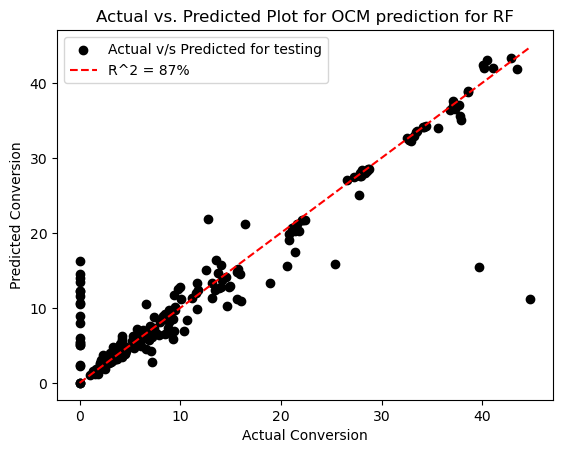

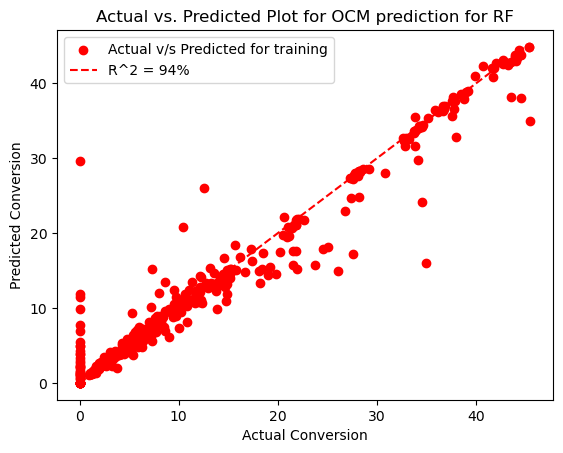

In [48]:
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(y_test, y2_pred, color='black', label='Actual v/s Predicted for testing')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label=f'R^2 = {r2_score(y_test,y2_pred)*100:.0f}%')

# Add labels and legend
plt.xlabel('Actual Conversion')
plt.ylabel('Predicted Conversion')

plt.title('Actual vs. Predicted Plot for OCM prediction for RF')
plt.legend()
plt.show()
# Show the plot
#plt.show()
plt.scatter(y_train, y3_pred, color='red', label='Actual v/s Predicted for training')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label= f'R^2 = {math.floor(r2_score(y_train,y3_pred)*100)}%')

# Add labels and legend
plt.xlabel('Actual Conversion')
plt.ylabel('Predicted Conversion')
plt.title('Actual vs. Predicted Plot for OCM prediction for RF')
plt.legend()

# Show the plot
plt.show()

In [50]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# Assuming X and y are your features and labels, and model is your model instance
k = 5

# Create a KFold object
kf = KFold(n_splits=k, random_state=115, shuffle=True)

acc_score = []

# Loop through each of the k-fold splits
for train_index, test_index in kf.split(X):
    # Use iloc to select rows by index
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model on the train set
    model.fit(X_train, y_train)

    # Predict on the test set
    pred_values = model.predict(X_test)

    # Calculate the accuracy score
    acc = r2_score(y_test, pred_values)

    # Append the score to the list
    acc_score.append(acc)

# Calculate the average accuracy score
avg_acc_score = sum(acc_score) / k

print(f"Average R2 Score: {avg_acc_score}")


#print the results
print('Accuracy of each fold - {}'.format(acc_score))
print('Average accuracy - {}'.format(avg_acc_score))

Average R2 Score: 0.8677533290819625
Accuracy of each fold - [0.8029789793861908, 0.9104321431202558, 0.8178683154224325, 0.9041551040667166, 0.9033321034142164]
Average accuracy - 0.8677533290819625


# Tree based models

In [303]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score


# Split data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Initialize and train the model
model = XGBRegressor(n_estimators=100, random_state=1010)
model.fit(X_train, y_train)

# Predict and evaluate on the test set
pred_values = model.predict(X_test)
r2 = r2_score(y_test, pred_values)
print(f"R2 Score on Test Set (XGBoost): {r2}")
print(f"R2 Score on Test Set (XGB): {r2_score(y_train, model.predict(X_train))}")

# K-Fold Cross-Validation
kf = KFold(n_splits=5, random_state=123, shuffle=True)
acc_score = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model.fit(X_train, y_train)
    pred_values = model.predict(X_test)
    acc = r2_score(y_test, pred_values)
    acc_score.append(acc)

avg_acc_score = sum(acc_score) / len(acc_score)
print(f"Average R2 Score (XGBoost - KFold): {avg_acc_score}")
print(acc_score)

R2 Score on Test Set (XGBoost): 0.8686793150745692
R2 Score on Test Set (XGB): 0.9997714970635968
Average R2 Score (XGBoost - KFold): 0.7904065824636126
[0.7627151633070781, 0.8295197241266119, 0.8654587738681406, 0.8892282997792569, 0.605110951236975]


In [125]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score


# Split data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=110)

# Initialize and train the model
model = CatBoostRegressor(iterations=1000, depth=10, learning_rate=0.1, verbose=0, random_state=1010)
model.fit(X_train, y_train)

# Predict and evaluate on the test set
pred_values = model.predict(X_test)
r2 = r2_score(y_test, pred_values)
print(f"R2 Score on Test Set (CatBoost): {r2}")
print(f"R2 Score on Train Set (CatBoost): {r2_score(y_train, model.predict(X_train))}")
print(f'MSE for Test: {mean_squared_error(y_test,pred_values,squared=True)}')

# K-Fold Cross-Validation
kf = KFold(n_splits=5, random_state=1010, shuffle=True)
acc_score = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model.fit(X_train, y_train)
    pred_values = model.predict(X_test)
    acc = r2_score(y_test, pred_values)
    acc_score.append(acc)

avg_acc_score = sum(acc_score) / len(acc_score)
print(f"Average R2 Score (Catboost - KFold): {avg_acc_score}")
print(acc_score)


R2 Score on Test Set (CatBoost): 0.8578968289514068
R2 Score on Train Set (CatBoost): 0.9999931235582292
MSE for Test: 29.094190351312456


'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


Average R2 Score (Catboost - KFold): 0.8270271796468652
[0.7792175541934434, 0.8195971626995843, 0.8515562916126339, 0.8268680607772575, 0.8578968289514068]


In [306]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score

## for best accuracy 1st run the code without commenting the following line and after that comment it out ##imp
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)

# Initialize and train the model
model = ExtraTreesRegressor(n_estimators=45, random_state=110,max_depth=20)
model.fit(X_train, y_train)

# Predict and evaluate on the test set
pred_values = model.predict(X_test)
r2 = r2_score(y_test, pred_values)
print(f"R2 Score on Test Set (Extra Trees): {r2}")
print(f"R2 Score on Test Set (Extra Trees): {r2_score(y_train, model.predict(X_train))}")
print(f'MSE for Test: {mean_squared_error(y_test,pred_values,squared=True)}')

# K-Fold Cross-Validation
kf = KFold(n_splits=5, random_state=1010, shuffle=True)
acc_score = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model.fit(X_train, y_train)
    pred_values = model.predict(X_test)
    acc = r2_score(y_test, pred_values)
    acc_score.append(acc)

avg_acc_score = sum(acc_score) / len(acc_score)
print(f"Average R2 Score (Extra Trees - KFold): {avg_acc_score}")
print(acc_score)

R2 Score on Test Set (Extra Trees): 0.8853981245067947
R2 Score on Test Set (Extra Trees): 0.9999999909769318
MSE for Test: 19.107371554752586


'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


Average R2 Score (Extra Trees - KFold): 0.8246358337972494
[0.7627109499171707, 0.7971542834138416, 0.8393031408311394, 0.8386126703173005, 0.8853981245067947]


In [307]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score

# Split data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)

# Initialize and train the model
model = lgb.LGBMRegressor(n_estimators=100, random_state=110, max_depth=20)
model.fit(X_train, y_train)

# Predict and evaluate on the test set
pred_values = model.predict(X_test)
r2 = r2_score(y_test, pred_values)
print(f"R2 Score on Test Set (LightGBM Regressor): {r2}")
print(f"R2 Score on Train Set (LightGBM Regressor): {r2_score(y_train, model.predict(X_train))}")
print(f'MSE for Test: {mean_squared_error(y_test,pred_values,squared=True)}')
# K-Fold Cross-Validation
kf = KFold(n_splits=5, random_state=1010, shuffle=True)
acc_score = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model.fit(X_train, y_train)
    pred_values = model.predict(X_test)
    acc = r2_score(y_test, pred_values)
    acc_score.append(acc)

avg_acc_score = sum(acc_score) / len(acc_score)
print(f"Average R2 Score (LightGBM Regressor - KFold): {avg_acc_score}")
print(acc_score)

R2 Score on Test Set (LightGBM Regressor): 0.856166058238182
R2 Score on Train Set (LightGBM Regressor): 0.9101653971773828
MSE for Test: 23.981183166506256


'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.


Average R2 Score (LightGBM Regressor - KFold): 0.8363807017006554
[0.7606405571932559, 0.7566476028662713, 0.9039641492047669, 0.9044851410008008, 0.856166058238182]


In [51]:
model

RandomForestRegressor(max_depth=15, min_samples_leaf=2, random_state=42)

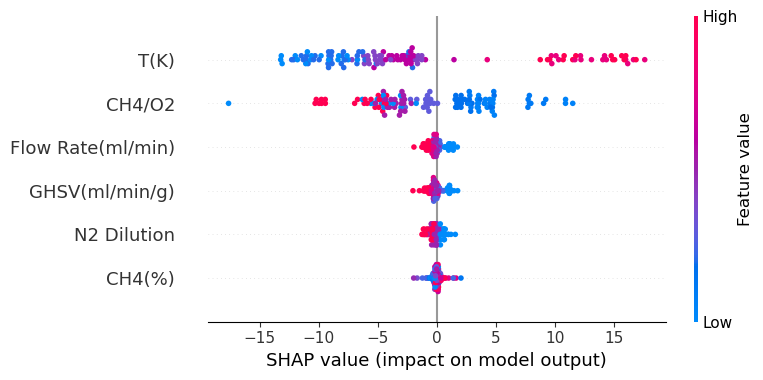

In [52]:
import shap

# Calculate SHAP values
explainer = shap.TreeExplainer(model)  # For tree-based models like RandomForest, XGBoost, etc.
shap_values = explainer.shap_values(X_test)  # Use the test set or any other dataset

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="dot")  # 'dot' is the default


In [54]:
# 2. SHAP Force Plot: Single prediction explanation
# Visualizing the first instance from the test set
shap.initjs()  # Enables JavaScript-based visualizations in Jupyter Notebooks
i = 1  # Index of the test instance
shap.force_plot(explainer.expected_value, shap_values[i], X_test.iloc[i])


Intercept: -214.74535693053397
Coefficient: 0.218049266770233


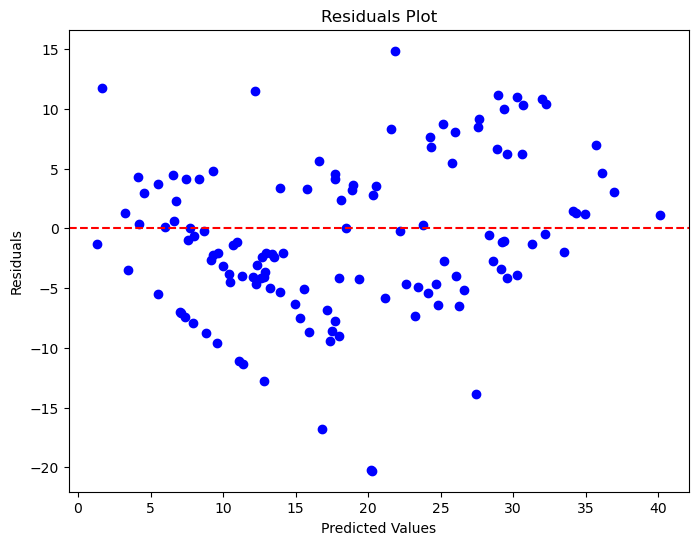

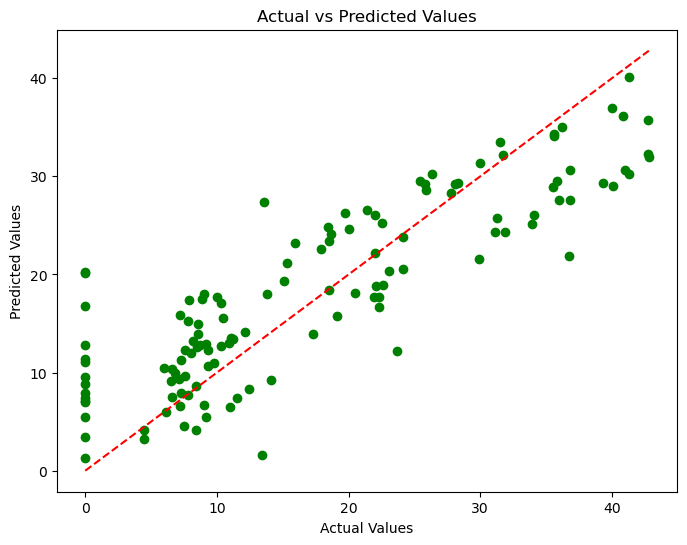

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# Step 2: Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 3: Make predictions on the test set
y_pred = model.predict(X_test)

# Step 4: Calculate residuals (errors)
residuals = y_test - y_pred

# Print model coefficients (Optional)
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")

# Step 5: Plot the residuals (Error between actual and predicted values)
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# Step 6: Plot actual vs predicted values (to visualize model fit)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


In [325]:
# 4. SHAP Waterfall Plot: Breaks down a specific prediction
# Visualize the contributions for a single test instance (index 0 in this case)
plt.figure()
for i in range(shap_values.shape[0]):
    shap.waterfall_plot(shap_values[i], X_test.iloc[i])
plt.show()

TypeError: The waterfall plot requires an `Explanation` object as the `shap_values` argument.

<Figure size 640x480 with 0 Axes>

In [161]:
# 4. SHAP Waterfall Plot: Breaks down a specific prediction
# Visualize the contributions for a single test instance (index 0 in this case)
plt.figure()
shap.waterfall_plot(shap_values, X_test)
plt.show()

TypeError: The waterfall plot requires an `Explanation` object as the `shap_values` argument.

<Figure size 640x480 with 0 Axes>

In [326]:
shap_values.shape

(123, 5)

# Data Analysis from best models

ExactExplainer explainer: 124it [00:14,  4.46it/s]                                                                     


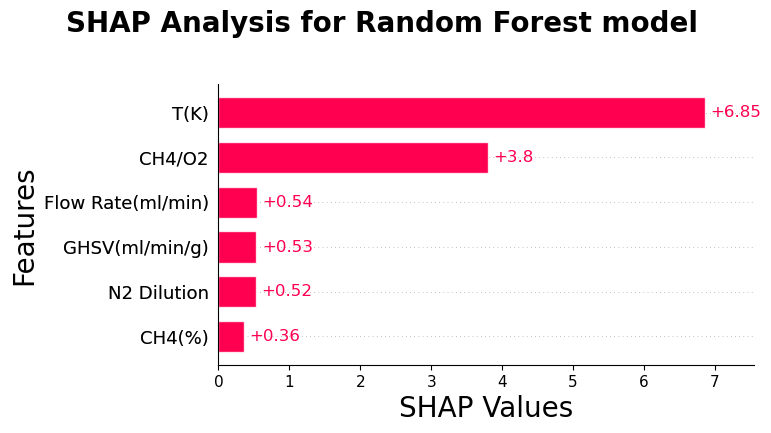

Text(0.5, 0.98, 'SHAP Analysis for Random Forest model')

<Figure size 640x480 with 0 Axes>

In [55]:
import shap

explainer = shap.Explainer(model.predict,X_test,feature_names=df.columns)
shap_values = explainer(X_test)

import matplotlib.pyplot as plt
plt.figure()
plt.suptitle('SHAP Analysis for Random Forest model', fontsize=20,fontweight="bold")

shap.plots.bar(shap_values,show= False)    #Bar plot
plt.ylabel('Features',fontsize=20)
plt.xlabel('SHAP Values',fontsize=20)
plt.tight_layout(pad=2)
plt.show()
plt.figure()
plt.suptitle('SHAP Analysis for Random Forest model')

In [ ]:
shap.partial_dependence_plot(
    "MedInc",
    model.predict,
    X100,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)